In [22]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [24]:
# Skip problematic characters
df = pd.read_csv('spam.csv', encoding='utf-8', encoding_errors='ignore')

In [25]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [26]:
df.shape

(5572, 5)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [28]:
df.drop(columns=['Unnamed: 2' , 'Unnamed: 3' , 'Unnamed: 4'] , inplace=True)

In [29]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [30]:
df.rename(columns={'v1' : 'target' , 'v2' : 'text'} , inplace=True)

In [31]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [32]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [33]:
df['target'] = encoder.fit_transform(df['target'])

In [34]:
df.head(3)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...


In [35]:
# missing values
df.isnull().sum()

,0
target,0
text,0


In [36]:
df.duplicated().sum() # duplicate value

np.int64(404)

In [37]:
df = df.drop_duplicates(keep='first')

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.shape

(5168, 2)

In [40]:
df['target'].value_counts()

,count
target,
0,4516
1,652


([<matplotlib.patches.Wedge at 0x7982bac4ce90>,
 [Text(-1.014725450968414, 0.42465545935140026, 'ham'),
  Text(1.0147253868472121, -0.42465561257067574, 'spam')])

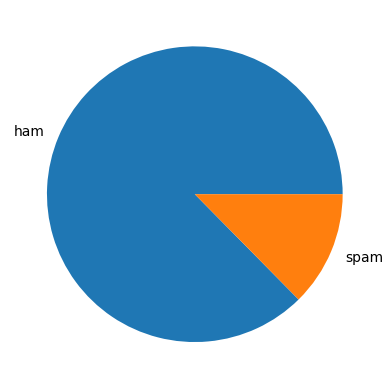

In [41]:
plt.pie(df['target'].value_counts() , labels=['ham' , 'spam'])

In [42]:
import nltk

In [62]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [63]:
df['num_char'] = df['text'].apply(len)

In [45]:
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [46]:
df['num_word'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [47]:
df['num_sent'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [48]:
df.head()

,target,text,num_char,num_word,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [49]:
df[['num_char' , 'num_word' , 'num_sent']].describe()

,num_char,num_word,num_sent
count,5168.000000,5168.000000,5168.000000
mean,78.759481,18.441176,1.966331
std,58.104099,13.327587,1.449367
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,116.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [50]:
df[df['target'] == 0][['num_char' , 'num_word' , 'num_sent']].describe() # ham

,num_char,num_word,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.344110,17.108946,1.819973
std,56.328803,13.494730,1.383228
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [51]:
df[df['target'] == 1][['num_char' , 'num_word' , 'num_sent']].describe() # spam

,num_char,num_word,num_sent
count,652.000000,652.000000,652.000000
mean,137.047546,27.668712,2.980061
std,29.937352,7.015283,1.491780
min,13.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,156.000000,32.000000,4.000000
max,222.000000,46.000000,9.000000


In [52]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

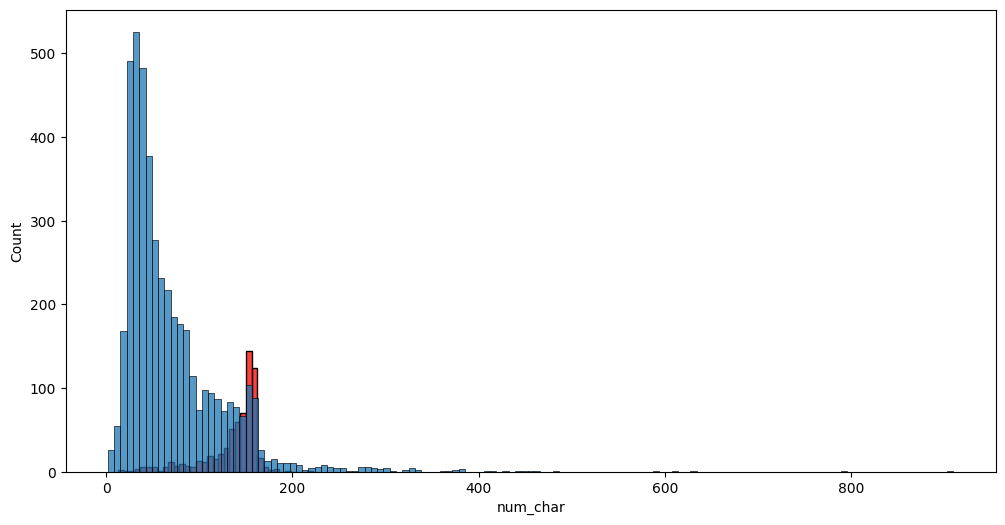

In [53]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 1]['num_char'] , color = 'red')
sns.histplot(df[df['target'] == 0]['num_char'])

<Axes: xlabel='num_word', ylabel='Count'>

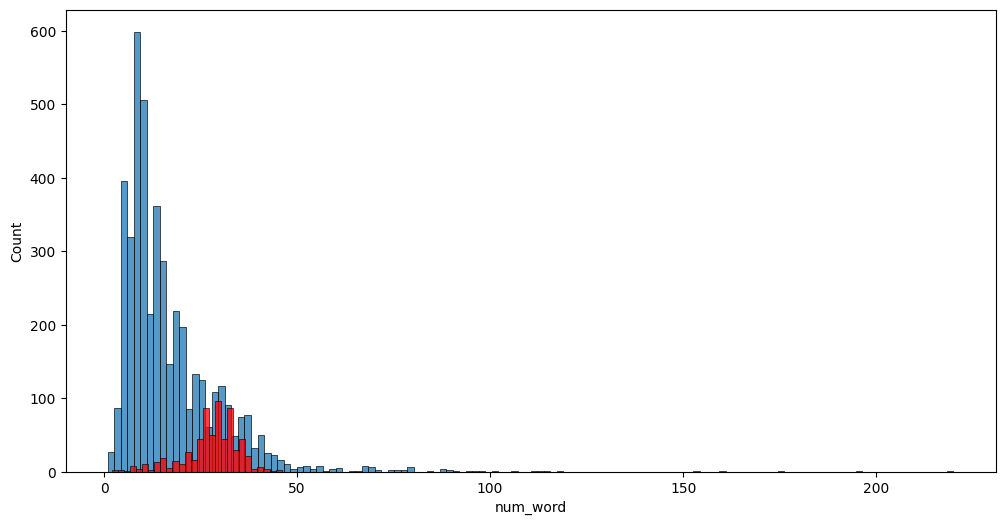

In [54]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_word'])
sns.histplot(df[df['target'] == 1]['num_word'] , color = 'red')

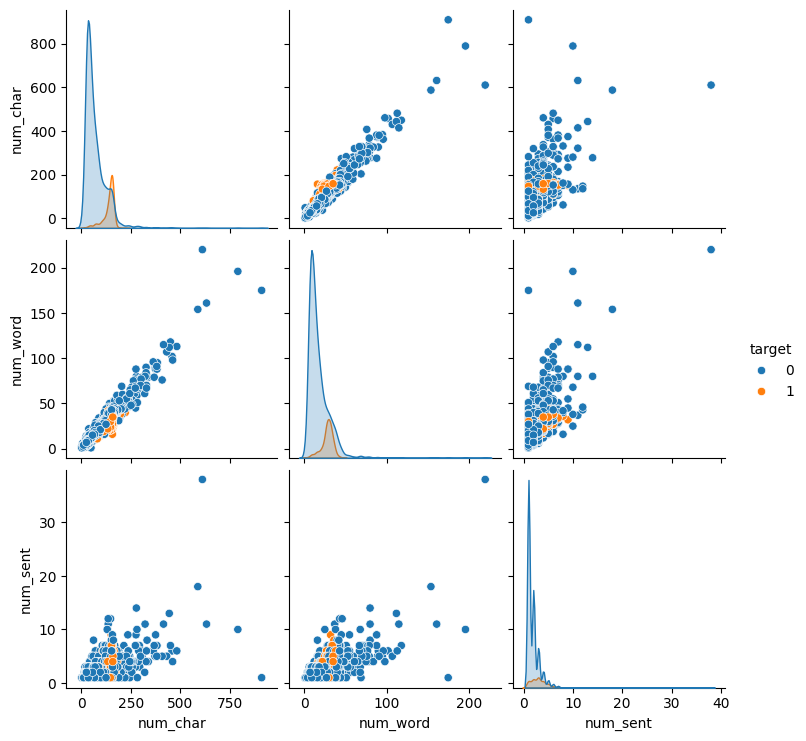

In [55]:
sns.pairplot(df , hue='target')

In [66]:
import string
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

# Initialize the stemmer
ps = PorterStemmer()

def transform_txt(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()
  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()
  for i in text:
    y.append(ps.stem(i)) # for changing text to lowest one ex -> dancing -> danc

  return " ".join(y)



In [67]:
transform_txt('hello MY NAME IS AJEET 123')

'hello name ajeet 123'

In [69]:
transform_txt(df['text'][0])

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [70]:
df['transform_text'] = df['text'].apply(transform_txt)

In [71]:
df.head()

,target,text,num_char,num_word,num_sent,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [72]:
!pip install wordcloud

In [73]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [74]:
spam_wc = wc.generate(df[df['target'] == 1]['transform_text'].str.cat(sep=" "))

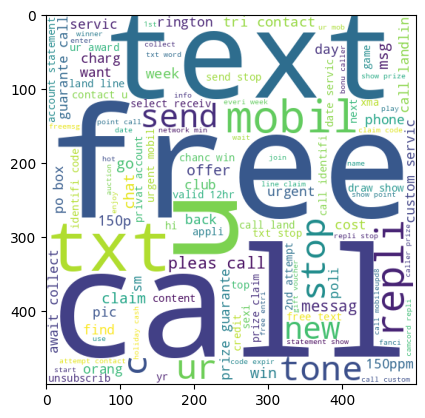

In [75]:
plt.imshow(spam_wc)

In [76]:
ham_wc = wc.generate(df[df['target'] == 0]['transform_text'].str.cat(sep=" "))

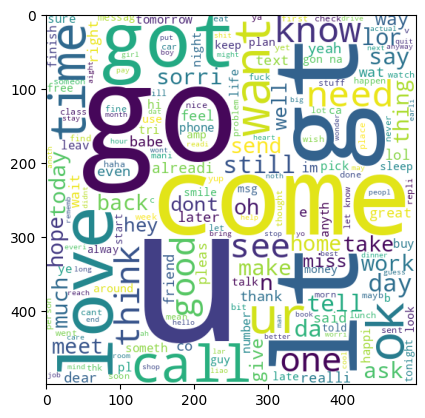

In [77]:
plt.imshow(ham_wc)

In [78]:
spam_ii = []
for mssg in df[df['target'] == 1]['transform_text'].tolist():
  for word in mssg.split():
    spam_ii.append(word)

In [79]:
len(spam_ii)

10106

In [80]:
from collections import Counter

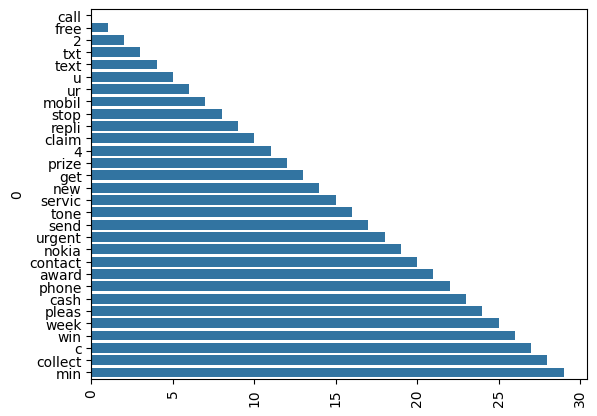

In [81]:
sns.barplot(pd.DataFrame(Counter(spam_ii).most_common(30))[0])
plt.xticks(rotation='vertical')
plt.show()

In [82]:
ham_ii = []
for mssg in df[df['target'] == 0]['transform_text'].tolist():
  for word in mssg.split():
    ham_ii.append(word)

In [83]:
len(ham_ii)

35380

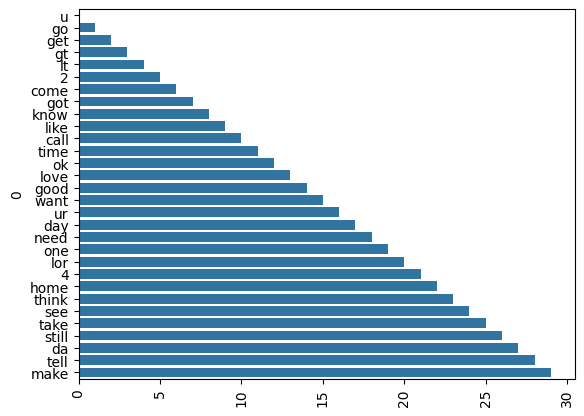

In [84]:
sns.barplot(pd.DataFrame(Counter(ham_ii).most_common(30))[0])
plt.xticks(rotation='vertical')
plt.show()

<h1> Model Building <h1/>

In [96]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [97]:
X = tfidf.fit_transform(df['transform_text']).toarray()

In [98]:
X.shape

(5168, 3000)

In [99]:
y = df['target'].values

In [100]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [101]:
from sklearn.model_selection import train_test_split

In [102]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=2)

In [103]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [104]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [105]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.874274661508704
[[789 104]
 [ 26 115]]
0.5251141552511416


In [106]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[893   0]
 [ 30 111]]
1.0


In [107]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))


0.9787234042553191
[[892   1]
 [ 21 120]]
0.9917355371900827


In [ ]:
# chosing -> mnb

In [108]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [109]:

# Download the vectorizer
from google.colab import files
files.download('vectorizer.pkl')

# Download the model
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>